# Global models and corrected ADME–Plain comparison

Addresses model ranking, R1.6–7 and R2 interpretation. Re-evaluate saved fitted models directly on the corrected input matrix.

**Mode:** executed analysis of the committed corrected results. Expensive model refitting is available through Notebook 11 and `scripts/reproduce.py`. Replaying saved results is not presented as fresh model training.

In [1]:
from pathlib import Path
import sys, json, itertools
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.revision-repository').exists())
sys.path.insert(0, str(ROOT / 'analysis'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from notebook_support import *
from analysis import PROTEINS, TARGET, FIXED, global_quantile, local_intervals
pd.set_option('display.max_columns', 14)
pd.set_option('display.max_rows', 30)
pd.set_option('display.precision', 5)


## Model inputs and frozen settings

Plain: master MW + logP + 2,048 molecular bits. Baseline adds 44 docking scores. PCA replaces those scores with three components. ADME adds 68 specified ADMETLab descriptors to Baseline. BBB pass uses Baseline features on its rule-defined subgroup. Hyperparameters are the published fixed choices; there is no new Optuna search.

In [2]:
params=read_json(ROOT/'data/source/beyond_rmse/results/models/experiment_config.json')['fixed_params']
display(pd.DataFrame(params).T)
adme=json.loads((ROOT/'data/source/admet_features.json').read_text())
assert len(adme)==68
display(pd.Series(adme,name='ADME feature').to_frame())

,iterations,depth,learning_rate,l2_leaf_reg,random_strength,bagging_temperature
Baseline,762.0,6.0,0.22486,4.41478,1.28018,0.19363
PCA,762.0,6.0,0.22486,4.41478,1.28018,0.19363
ADME,362.0,8.0,0.12057,6.38793,0.31204,0.77997
Plain,708.0,7.0,0.14074,3.53675,1.59300,3.23490
BBB pass,614.0,7.0,0.14978,1.02004,1.65514,1.18529


,ADME feature
0,Vol
1,Dense
2,nHA
3,nHD
4,TPSA
...,...
63,CYP2B6-sub
64,CYP2C8-inh
65,LM-human
66,cl-plasma


## Verify the models, not only the summary CSV

Load each fitted model and its saved median imputer/PCA. Recreate the test matrix by ligand_id, predict and compare to the recorded per-molecule values. The strict cohort is a separate exact-identity sensitivity analysis.

In [3]:
verified=[]
for seed in range(42,47):
    for name in ['Baseline','PCA','ADME','Plain','BBB pass']:
        verified.append(verify_model(seed,name))
    for name in ['ADME','Plain']:
        verified.append(verify_model(seed,name,strict=True))
verified=pd.DataFrame(verified)
assert len(verified)==35
display(verified.groupby(['strict','model']).agg(n_fits=('seed','size'),max_prediction_difference=('max_prediction_difference','max')))

/Users/adeliyaleleytner/Documents/Документы — MacBook Air — Аделия/Claude/Projects/Docking and MIE/beyond-rmse-revision/analysis/notebook_support.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for j in range(3):x[f'PC{j+1}']=pc[:,j]
/Users/adeliyaleleytner/Documents/Документы — MacBook Air — Аделия/Claude/Projects/Docking and MIE/beyond-rmse-revision/analysis/notebook_support.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for j in range(3):x[f'PC{j+1}']=pc[:,j]
/Users/adeliyaleleytner/Documents/Документы — MacBook Ai

/Users/adeliyaleleytner/Documents/Документы — MacBook Air — Аделия/Claude/Projects/Docking and MIE/beyond-rmse-revision/analysis/notebook_support.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for j in range(3):x[f'PC{j+1}']=pc[:,j]
/Users/adeliyaleleytner/Documents/Документы — MacBook Air — Аделия/Claude/Projects/Docking and MIE/beyond-rmse-revision/analysis/notebook_support.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for j in range(3):x[f'PC{j+1}']=pc[:,j]
/Users/adeliyaleleytner/Documents/Документы — MacBook Ai

/Users/adeliyaleleytner/Documents/Документы — MacBook Air — Аделия/Claude/Projects/Docking and MIE/beyond-rmse-revision/analysis/notebook_support.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for j in range(3):x[f'PC{j+1}']=pc[:,j]
/Users/adeliyaleleytner/Documents/Документы — MacBook Air — Аделия/Claude/Projects/Docking and MIE/beyond-rmse-revision/analysis/notebook_support.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for j in range(3):x[f'PC{j+1}']=pc[:,j]
/Users/adeliyaleleytner/Documents/Документы — MacBook Ai

/Users/adeliyaleleytner/Documents/Документы — MacBook Air — Аделия/Claude/Projects/Docking and MIE/beyond-rmse-revision/analysis/notebook_support.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for j in range(3):x[f'PC{j+1}']=pc[:,j]
/Users/adeliyaleleytner/Documents/Документы — MacBook Air — Аделия/Claude/Projects/Docking and MIE/beyond-rmse-revision/analysis/notebook_support.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for j in range(3):x[f'PC{j+1}']=pc[:,j]
/Users/adeliyaleleytner/Documents/Документы — MacBook Ai

/Users/adeliyaleleytner/Documents/Документы — MacBook Air — Аделия/Claude/Projects/Docking and MIE/beyond-rmse-revision/analysis/notebook_support.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for j in range(3):x[f'PC{j+1}']=pc[:,j]
/Users/adeliyaleleytner/Documents/Документы — MacBook Air — Аделия/Claude/Projects/Docking and MIE/beyond-rmse-revision/analysis/notebook_support.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for j in range(3):x[f'PC{j+1}']=pc[:,j]
/Users/adeliyaleleytner/Documents/Документы — MacBook Ai

n_fits  max_prediction_difference
strict model                                      
False  ADME           5                8.88178e-16
       BBB pass       5                8.88178e-16
       Baseline       5                8.88178e-16
       PCA            5                8.88178e-16
       Plain          5                8.88178e-16
True   ADME           5                8.88178e-16
       Plain          5                8.88178e-16

In [4]:
metrics=table('global_models/metrics.csv')
display(metrics.groupby('model')[['rmse','mae','r2','spearman','ccc']].agg(['mean','std']))
comp=table('strict_global_comparison.csv')
display(comp)
assert (comp.rmse_ADME<comp.rmse_Plain).all()

rmse               mae                r2          spearman  \
             mean      std     mean      std     mean      std     mean   
model                                                                     
ADME      0.49304  0.00671  0.34202  0.00261  0.52014  0.01411  0.71126   
BBB pass  0.47591  0.01422  0.33206  0.00650  0.38802  0.03173  0.63594   
Baseline  0.52501  0.01009  0.36666  0.00347  0.45603  0.01307  0.66969   
PCA       0.52442  0.01208  0.36476  0.00612  0.45729  0.01534  0.67284   
Plain     0.51217  0.01610  0.35453  0.00751  0.48257  0.01273  0.68882   

                       ccc           
              std     mean      std  
model                                
ADME      0.01416  0.67817  0.01200  
BBB pass  0.01506  0.56310  0.02566  
Baseline  0.01350  0.63576  0.01465  
PCA       0.01592  0.63224  0.02182  
Plain     0.00819  0.64982  0.01528

,cohort,seed,n_test,rmse_ADME,rmse_Plain,mse_ADME_minus_Plain,ci_low,ci_high
0,primary,42,2532,0.48717,0.50280,-0.01547,-0.02883,-0.00045
1,primary,43,2459,0.49468,0.51243,-0.01787,-0.03291,-0.00443
2,primary,44,2387,0.49051,0.51517,-0.02481,-0.03786,-0.01282
3,primary,45,2554,0.50397,0.53668,-0.03404,-0.05302,-0.01689
4,primary,46,2550,0.48887,0.49376,-0.00480,-0.01700,0.00749
5,strict_exact_identity,42,2464,0.48382,0.50973,-0.02574,-0.03917,-0.01146
6,strict_exact_identity,43,2392,0.49371,0.51256,-0.01896,-0.03091,-0.00738
7,strict_exact_identity,44,2332,0.49239,0.51852,-0.02641,-0.04034,-0.01310
8,strict_exact_identity,45,2500,0.51020,0.54259,-0.03410,-0.05986,-0.01317
9,strict_exact_identity,46,2494,0.48409,0.50044,-0.01609,-0.02859,-0.00344


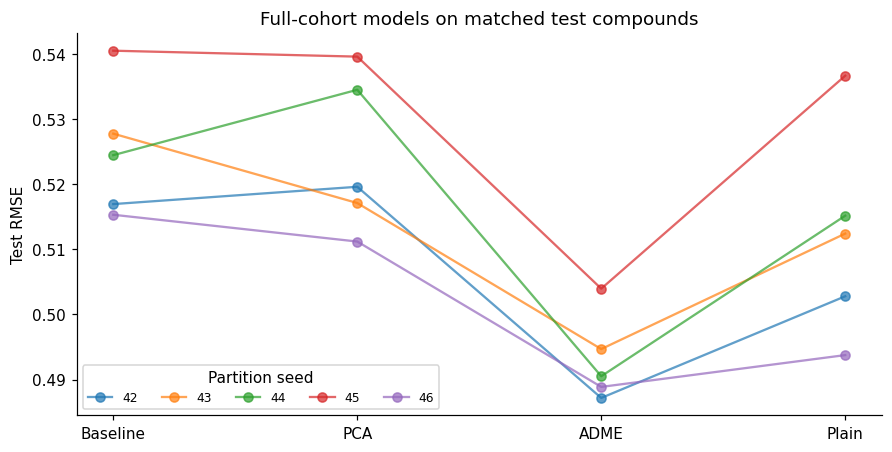

In [5]:
order=['Baseline','PCA','ADME','Plain'];fig,ax=plt.subplots(figsize=(8,4),layout='constrained')
for seed in range(42,47):
    g=metrics[metrics.seed.eq(seed)].set_index('model').loc[order]
    ax.plot(order,g.rmse,'o-',alpha=.7,label=str(seed))
ax.set(ylabel='Test RMSE',title='Full-cohort models on matched test compounds')
ax.legend(title='Partition seed',ncol=5,fontsize=8);finish(fig,'full_cohort_model_comparison')

## Interpretation

ADME wins over Plain on all five primary and five strict partitions. Five partitions overlap and are not independent studies. This comparison supports the evaluated ADME configuration, not a causal estimate of a feature block. BBB subset metrics must not be ranked against full-cohort metrics (Notebook 06). Changes in the reanalysis include both identity repair and evaluation protocol; the old-to-new metric difference is not solely an ADMET-repair effect.

,seed,model,n_train,n_calibration,n_test,trees,rmse,...,coverage_0.9,width_0.9,coverage_0.95,width_0.95,interval_score_90,mse,ccc
0,42,Baseline,7910,2142,2532,578,0.51696,...,0.91706,1.73509,0.95893,2.27801,2.41537,0.26725,0.64172
1,42,PCA,7910,2142,2532,416,0.51962,...,0.90403,1.66239,0.95735,2.32235,2.44331,0.27000,0.63350
2,42,ADME,7910,2142,2532,339,0.48717,...,0.90956,1.57610,0.95932,2.19171,2.29607,0.23734,0.68382
3,42,Plain,7910,2142,2532,702,0.50280,...,0.91509,1.66438,0.96169,2.28656,2.34604,0.25280,0.65683
4,42,BBB pass,5405,1440,1714,396,0.45829,...,0.89557,1.42850,0.95391,1.89502,2.11334,0.21003,0.60571


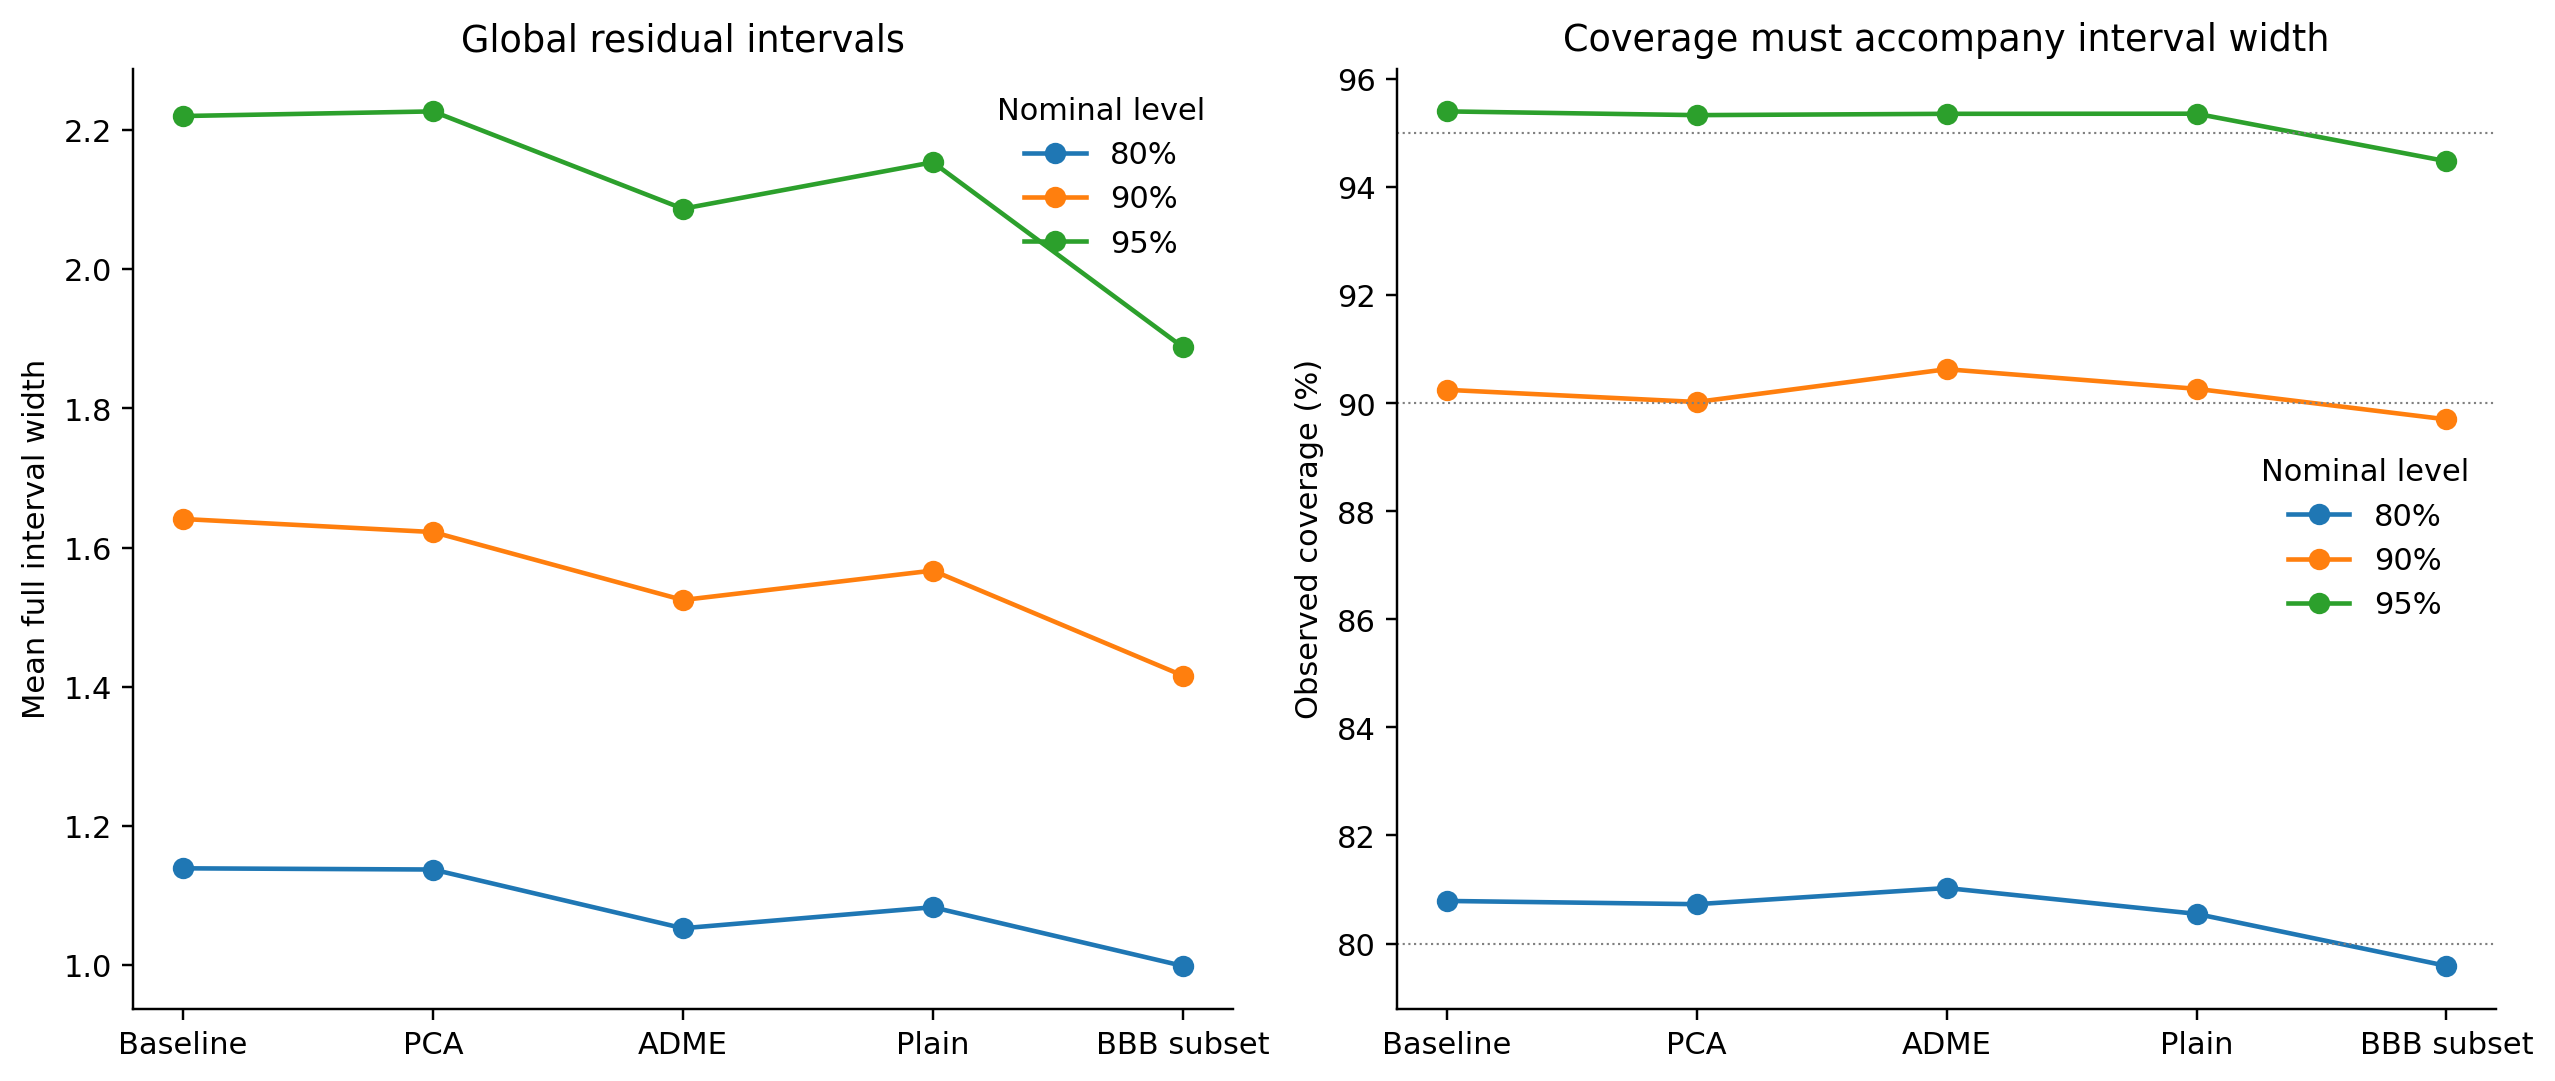

In [6]:
display(table('tables/table1_primary_global_models.csv'))
figure('results/repaired/figures/figure2_revised.png')